 STOCK MARKET PORTFOLIO ANALYZER

Upload your stock price CSV file.
Required columns: Date, Ticker, Sector, Close, Quantity



Saving stock_prices.csv to stock_prices (1).csv

 File uploaded: stock_prices (1).csv
Rows loaded: 180
 Date range: 2026-07-01 → 2026-07-30
 Stocks: 6
 Sectors: 5

First 5 rows:


,Date,Ticker,Sector,Close,Quantity
0,2026-07-01,HDFCBANK,Banking,1702.73,8
1,2026-07-01,INFY,IT,1554.72,7
2,2026-07-01,ITC,FMCG,508.29,15
3,2026-07-01,RELIANCE,Energy,1463.82,10
4,2026-07-01,SUNPHARMA,Healthcare,1779.90,6



💰 PORTFOLIO SUMMARY
Total Investment : ₹73,269.33
Current Value    : ₹75,963.26
Profit / Loss    : ₹2,693.93
Overall Return   : 3.68%

🏆 BEST & WORST PERFORMERS
🏆 Best Performer : TCS (12.15%)
⚠️ Worst Performer: HDFCBANK (-5.69%)

📊 STOCK PERFORMANCE


,Ticker,Sector,Buy Price,Quantity,Current Price,Investment,Current Value,Profit/Loss,Return %
0,TCS,IT,"₹3,164.50",5,"₹3,549.12","₹15,822.50","₹17,745.60","₹1,923.10",12.15%
1,SUNPHARMA,Healthcare,"₹1,779.90",6,"₹1,938.63","₹10,679.40","₹11,631.78",₹952.38,8.92%
2,INFY,IT,"₹1,554.72",7,"₹1,667.81","₹10,883.04","₹11,674.67",₹791.63,7.27%
3,ITC,FMCG,₹508.29,15,₹519.17,"₹7,624.35","₹7,787.55",₹163.20,2.14%
4,RELIANCE,Energy,"₹1,463.82",10,"₹1,427.71","₹14,638.20","₹14,277.10",₹-361.10,-2.47%
5,HDFCBANK,Banking,"₹1,702.73",8,"₹1,605.82","₹13,621.84","₹12,846.56",₹-775.28,-5.69%



🏭 SECTOR-WISE INVESTMENT


,Sector,Investment,Current_Value,Profit_Loss,Return %
0,IT,"₹26,705.54","₹29,420.27","₹2,714.73",10.17%
1,Energy,"₹14,638.20","₹14,277.10",₹-361.10,-2.47%
2,Banking,"₹13,621.84","₹12,846.56",₹-775.28,-5.69%
3,Healthcare,"₹10,679.40","₹11,631.78",₹952.38,8.92%
4,FMCG,"₹7,624.35","₹7,787.55",₹163.20,2.14%



🤖 MOVING AVERAGE TREND


,Ticker,Latest Price,5-Day Moving Average,Trend
0,HDFCBANK,"₹1,605.82","₹1,641.33",DOWN
1,INFY,"₹1,667.81","₹1,637.38",UP
2,ITC,₹519.17,₹515.21,UP
3,RELIANCE,"₹1,427.71","₹1,428.53",DOWN
4,SUNPHARMA,"₹1,938.63","₹1,957.33",DOWN
5,TCS,"₹3,549.12","₹3,700.18",DOWN


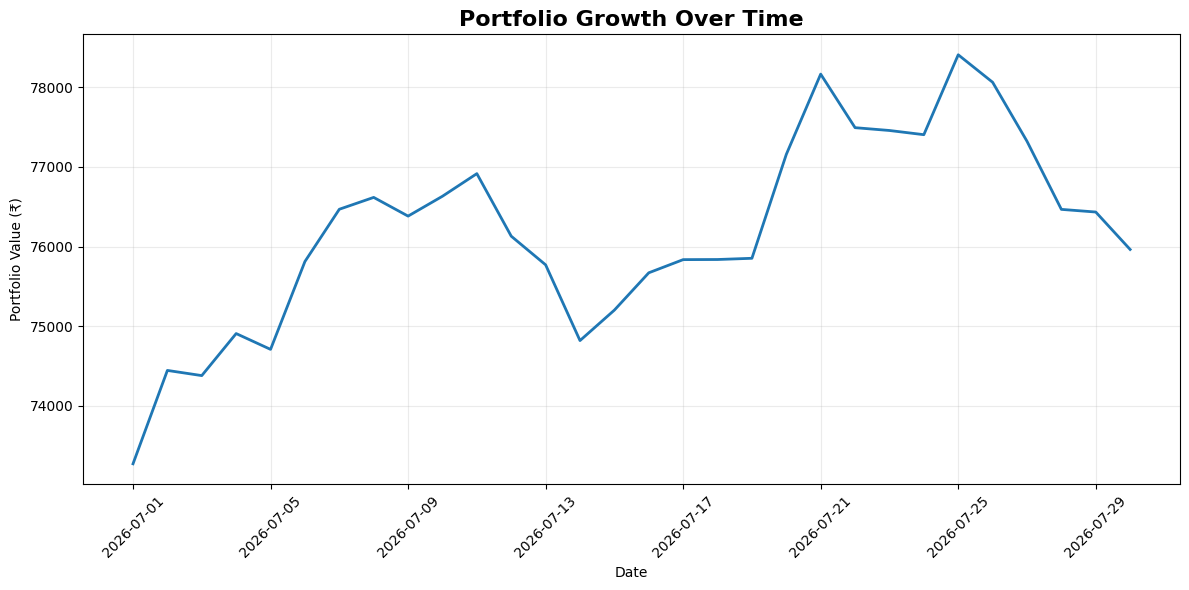

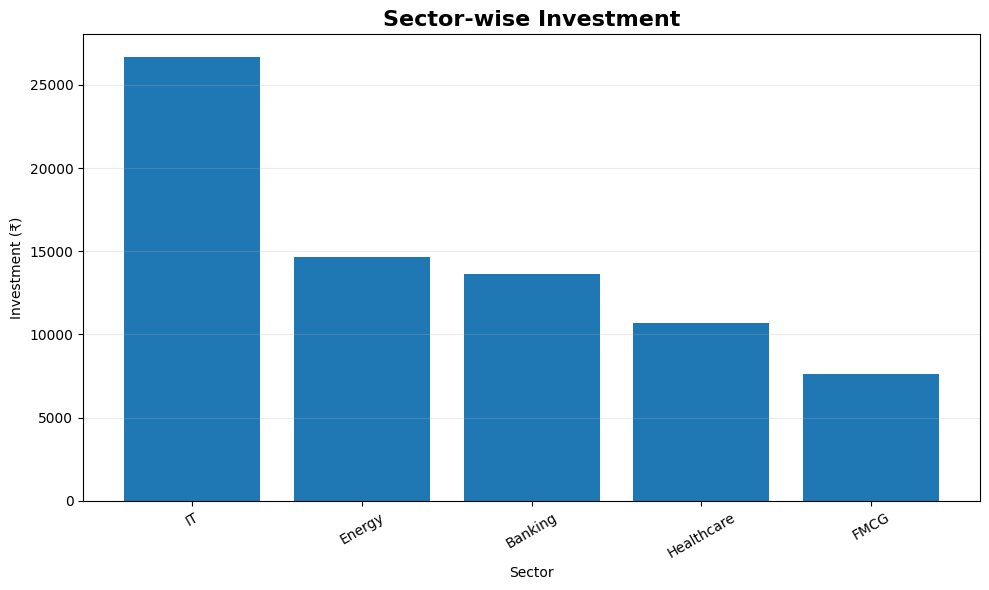

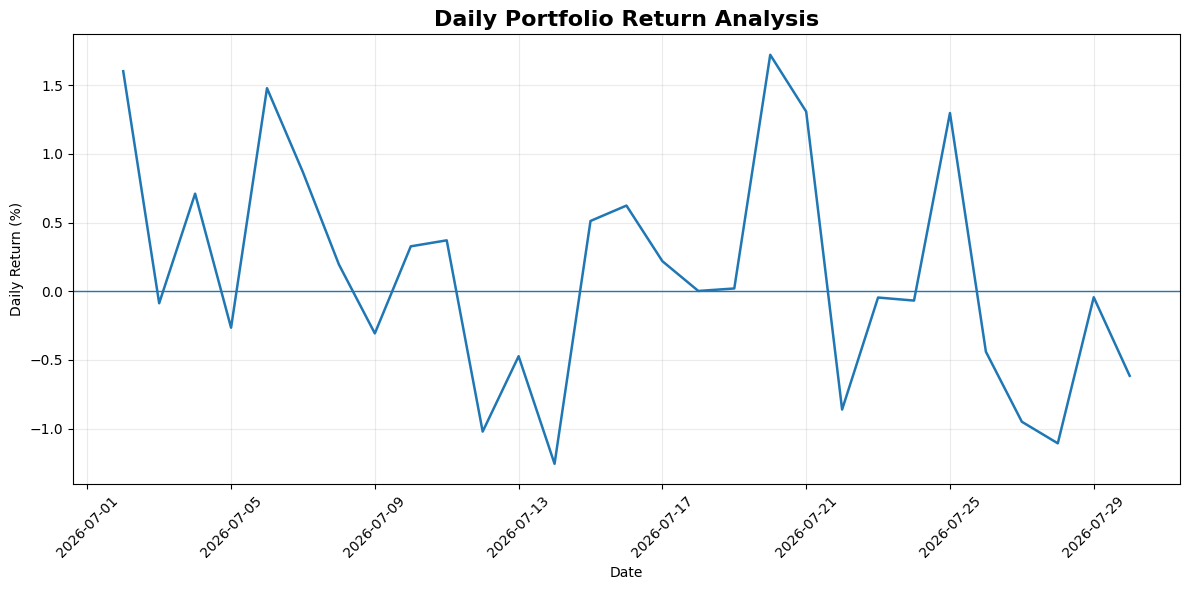

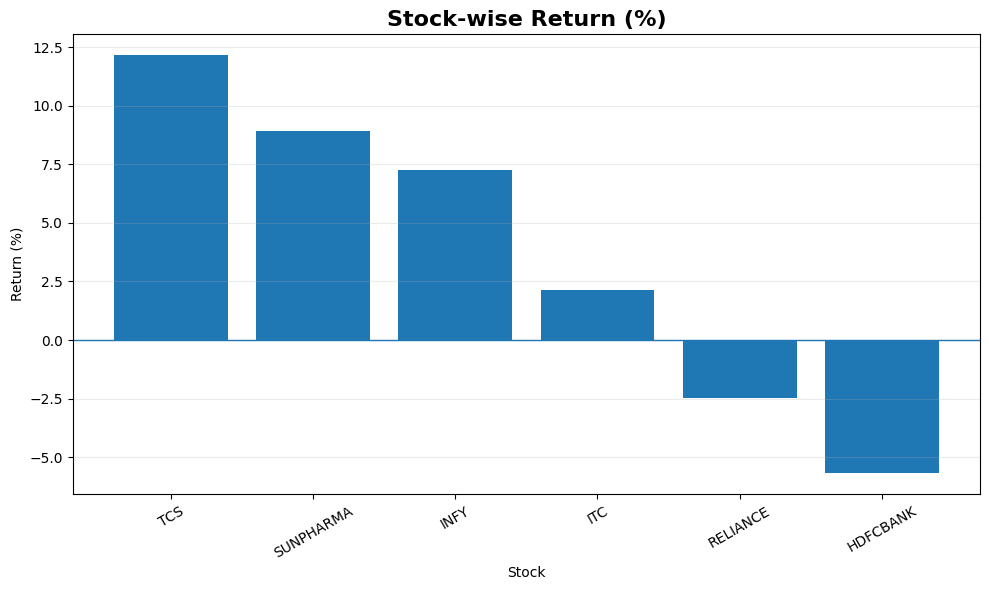


 ANALYSIS COMPLETE

Generated charts:
 portfolio_growth.png
 sector_wise_investment.png
 daily_return_analysis.png
 stock_performance.png

Generated reports:
 portfolio_report.csv
 daily_returns.csv
 sector_analysis.csv
 moving_average_prediction.csv

 Complete project output: /content/Day28_Stock_Portfolio_Analyzer.zip

⬇ Downloading ZIP file...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Done!
Your ZIP contains all charts and CSV reports.


In [2]:

# =========================
# 1. INSTALL / IMPORT
# =========================

import os
import shutil
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from IPython.display import display

warnings.filterwarnings("ignore")

# Create output folder
OUTPUT_DIR = "portfolio_analyzer_output"
CHART_DIR = os.path.join(OUTPUT_DIR, "charts")
os.makedirs(CHART_DIR, exist_ok=True)


# =========================
# 2. UPLOAD CSV
# =========================

print("=" * 70)
print(" STOCK MARKET PORTFOLIO ANALYZER")
print("=" * 70)
print("\nUpload your stock price CSV file.")
print("Required columns: Date, Ticker, Sector, Close, Quantity\n")

uploaded = files.upload()

if not uploaded:
    raise ValueError("No CSV file was uploaded.")

csv_file = next(iter(uploaded.keys()))

if not csv_file.lower().endswith(".csv"):
    raise ValueError("Please upload a CSV file.")

print(f"\n File uploaded: {csv_file}")


# =========================
# 3. LOAD & VALIDATE DATA
# =========================

df = pd.read_csv(csv_file)

required_columns = {
    "Date",
    "Ticker",
    "Sector",
    "Close",
    "Quantity"
}

missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(
        f" Missing required columns: {sorted(missing_columns)}\n"
        f"Your CSV must contain: {sorted(required_columns)}"
    )

# Clean column names
df.columns = df.columns.str.strip()

# Convert data types
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")

# Remove invalid rows
df = df.dropna(
    subset=["Date", "Ticker", "Sector", "Close", "Quantity"]
).copy()

# Remove impossible values
df = df[df["Close"] > 0]
df = df[df["Quantity"] > 0]

# Sort data
df = df.sort_values(["Date", "Ticker"]).reset_index(drop=True)

if df.empty:
    raise ValueError("❌ No valid rows found in the uploaded CSV.")

print(f"Rows loaded: {len(df):,}")
print(f" Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f" Stocks: {df['Ticker'].nunique()}")
print(f" Sectors: {df['Sector'].nunique()}")

print("\nFirst 5 rows:")
display(df.head())


# =========================
# 4. STOCK-LEVEL ANALYSIS
# =========================

# First available record = assumed purchase price
first_prices = (
    df.sort_values("Date")
      .groupby("Ticker", as_index=False)
      .first()
)

# Latest available record = current price
latest_prices = (
    df.sort_values("Date")
      .groupby("Ticker", as_index=False)
      .last()
)

# Rename columns for clarity
first_prices = first_prices[
    ["Ticker", "Sector", "Close", "Quantity"]
].rename(
    columns={
        "Close": "Buy Price"
    }
)

latest_prices = latest_prices[
    ["Ticker", "Close"]
].rename(
    columns={
        "Close": "Current Price"
    }
)

# Merge
portfolio = pd.merge(
    first_prices,
    latest_prices,
    on="Ticker",
    how="inner"
)

# Calculations
portfolio["Investment"] = (
    portfolio["Buy Price"] *
    portfolio["Quantity"]
)

portfolio["Current Value"] = (
    portfolio["Current Price"] *
    portfolio["Quantity"]
)

portfolio["Profit/Loss"] = (
    portfolio["Current Value"] -
    portfolio["Investment"]
)

portfolio["Return %"] = (
    portfolio["Profit/Loss"] /
    portfolio["Investment"]
) * 100

# Sort by performance
portfolio = portfolio.sort_values(
    "Return %",
    ascending=False
).reset_index(drop=True)


# =========================
# 5. PORTFOLIO SUMMARY
# =========================

total_investment = portfolio["Investment"].sum()
current_value = portfolio["Current Value"].sum()
total_profit_loss = current_value - total_investment

if total_investment != 0:
    overall_return = (
        total_profit_loss /
        total_investment
    ) * 100
else:
    overall_return = 0


# =========================
# 6. BEST / WORST STOCK
# =========================

best_stock = portfolio.iloc[0]
worst_stock = portfolio.iloc[-1]


# =========================
# 7. DAILY PORTFOLIO VALUE
# =========================

# Each stock's daily value = Close × Quantity
df["Position Value"] = (
    df["Close"] *
    df["Quantity"]
)

daily_portfolio = (
    df.groupby("Date", as_index=False)
      .agg(
          Portfolio_Value=("Position Value", "sum")
      )
      .sort_values("Date")
)

# Daily return
daily_portfolio["Daily Return %"] = (
    daily_portfolio["Portfolio_Value"]
    .pct_change()
    * 100
)

# Cumulative return
starting_value = daily_portfolio["Portfolio_Value"].iloc[0]

daily_portfolio["Cumulative Return %"] = (
    (
        daily_portfolio["Portfolio_Value"] /
        starting_value
    ) - 1
) * 100


# =========================
# 8. SECTOR-WISE ANALYSIS
# =========================

sector_analysis = (
    portfolio
    .groupby("Sector", as_index=False)
    .agg(
        Investment=("Investment", "sum"),
        Current_Value=("Current Value", "sum"),
        Profit_Loss=("Profit/Loss", "sum")
    )
)

sector_analysis["Return %"] = (
    sector_analysis["Profit_Loss"] /
    sector_analysis["Investment"]
) * 100

sector_analysis = sector_analysis.sort_values(
    "Investment",
    ascending=False
).reset_index(drop=True)


# =========================
# 9. MOVING AVERAGE ANALYSIS
# =========================

MA_WINDOW = 5

moving_average_rows = []

for ticker, stock_data in df.groupby("Ticker"):

    stock_data = stock_data.sort_values("Date")

    latest_price = stock_data["Close"].iloc[-1]

    moving_average = (
        stock_data["Close"]
        .tail(MA_WINDOW)
        .mean()
    )

    if latest_price > moving_average:
        trend = "UP "
    elif latest_price < moving_average:
        trend = "DOWN "
    else:
        trend = "SIDEWAYS "

    moving_average_rows.append({
        "Ticker": ticker,
        "Latest Price": latest_price,
        f"{MA_WINDOW}-Day Moving Average": moving_average,
        "Trend": trend
    })

moving_average_df = pd.DataFrame(
    moving_average_rows
)


# =========================
# 10. DISPLAY RESULTS
# =========================

print("\n" + "=" * 70)
print("💰 PORTFOLIO SUMMARY")
print("=" * 70)

print(f"Total Investment : ₹{total_investment:,.2f}")
print(f"Current Value    : ₹{current_value:,.2f}")
print(f"Profit / Loss    : ₹{total_profit_loss:,.2f}")
print(f"Overall Return   : {overall_return:.2f}%")

print("\n" + "=" * 70)
print("🏆 BEST & WORST PERFORMERS")
print("=" * 70)

print(
    f"🏆 Best Performer : "
    f"{best_stock['Ticker']} "
    f"({best_stock['Return %']:.2f}%)"
)

print(
    f"⚠️ Worst Performer: "
    f"{worst_stock['Ticker']} "
    f"({worst_stock['Return %']:.2f}%)"
)

print("\n" + "=" * 70)
print("📊 STOCK PERFORMANCE")
print("=" * 70)

display(
    portfolio.style.format({
        "Buy Price": "₹{:,.2f}",
        "Current Price": "₹{:,.2f}",
        "Investment": "₹{:,.2f}",
        "Current Value": "₹{:,.2f}",
        "Profit/Loss": "₹{:,.2f}",
        "Return %": "{:.2f}%"
    })
)

print("\n" + "=" * 70)
print("🏭 SECTOR-WISE INVESTMENT")
print("=" * 70)

display(
    sector_analysis.style.format({
        "Investment": "₹{:,.2f}",
        "Current_Value": "₹{:,.2f}",
        "Profit_Loss": "₹{:,.2f}",
        "Return %": "{:.2f}%"
    })
)

print("\n" + "=" * 70)
print("🤖 MOVING AVERAGE TREND")
print("=" * 70)

display(
    moving_average_df.style.format({
        "Latest Price": "₹{:,.2f}",
        f"{MA_WINDOW}-Day Moving Average": "₹{:,.2f}"
    })
)


# =========================
# 11. CHART 1
# PORTFOLIO GROWTH
# =========================

plt.figure(figsize=(12, 6))

plt.plot(
    daily_portfolio["Date"],
    daily_portfolio["Portfolio_Value"],
    linewidth=2
)

plt.title(
    "Portfolio Growth Over Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value (₹)")

plt.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()

portfolio_growth_path = os.path.join(
    CHART_DIR,
    "portfolio_growth.png"
)

plt.savefig(
    portfolio_growth_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()


# =========================
# 12. CHART 2
# SECTOR-WISE INVESTMENT
# =========================

plt.figure(figsize=(10, 6))

plt.bar(
    sector_analysis["Sector"],
    sector_analysis["Investment"]
)

plt.title(
    "Sector-wise Investment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sector")
plt.ylabel("Investment (₹)")

plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30)
plt.tight_layout()

sector_chart_path = os.path.join(
    CHART_DIR,
    "sector_wise_investment.png"
)

plt.savefig(
    sector_chart_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()


# =========================
# 13. CHART 3
# DAILY RETURN ANALYSIS
# =========================

plt.figure(figsize=(12, 6))

plt.plot(
    daily_portfolio["Date"],
    daily_portfolio["Daily Return %"],
    linewidth=1.8
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title(
    "Daily Portfolio Return Analysis",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Daily Return (%)")

plt.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()

daily_return_path = os.path.join(
    CHART_DIR,
    "daily_return_analysis.png"
)

plt.savefig(
    daily_return_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()


# =========================
# 14. CHART 4
# STOCK PERFORMANCE
# =========================

plt.figure(figsize=(10, 6))

plt.bar(
    portfolio["Ticker"],
    portfolio["Return %"]
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title(
    "Stock-wise Return (%)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Stock")
plt.ylabel("Return (%)")

plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30)
plt.tight_layout()

stock_return_path = os.path.join(
    CHART_DIR,
    "stock_performance.png"
)

plt.savefig(
    stock_return_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()


# =========================
# 15. SAVE CSV REPORTS
# =========================

portfolio_report_path = os.path.join(
    OUTPUT_DIR,
    "portfolio_report.csv"
)

daily_returns_path = os.path.join(
    OUTPUT_DIR,
    "daily_returns.csv"
)

sector_report_path = os.path.join(
    OUTPUT_DIR,
    "sector_analysis.csv"
)

moving_average_path = os.path.join(
    OUTPUT_DIR,
    "moving_average_prediction.csv"
)

portfolio.to_csv(
    portfolio_report_path,
    index=False
)

daily_portfolio.to_csv(
    daily_returns_path,
    index=False
)

sector_analysis.to_csv(
    sector_report_path,
    index=False
)

moving_average_df.to_csv(
    moving_average_path,
    index=False
)


# =========================
# 16. CREATE ZIP FILE
# =========================

zip_path = shutil.make_archive(
    "Day28_Stock_Portfolio_Analyzer",
    "zip",
    OUTPUT_DIR
)

print("\n" + "=" * 70)
print(" ANALYSIS COMPLETE")
print("=" * 70)

print("\nGenerated charts:")
print(" portfolio_growth.png")
print(" sector_wise_investment.png")
print(" daily_return_analysis.png")
print(" stock_performance.png")

print("\nGenerated reports:")
print(" portfolio_report.csv")
print(" daily_returns.csv")
print(" sector_analysis.csv")
print(" moving_average_prediction.csv")

print(f"\n Complete project output: {zip_path}")


# =========================
# 17. DOWNLOAD EVERYTHING
# =========================

print("\n⬇ Downloading ZIP file...")

files.download(zip_path)

print("\n Done!")
print("Your ZIP contains all charts and CSV reports.")
